In [33]:
import torchvision
import torch
import torchvision.transforms as transforms
import os
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import ssl
# Tell Python to ignore the broken network SSL certificates for downloads
ssl._create_default_https_context = ssl._create_unverified_context

In [34]:
# 1. FIXED: Removed Path.home() so Python targets your actual C drive directories directly
train_dataset_path = r"C:\School\Year 3\Semester 1\EGL 314 - Media Solutioning & Project 1\Project\Dataset\Training"
test_dataset_path =  r"C:\School\Year 3\Semester 1\EGL 314 - Media Solutioning & Project 1\Project\Dataset\Validation"

In [35]:
mean = [0.4363, 0.4328, 0.3291]
std = [0.2129, 0.2075, 0.2037]

train_transforms = transforms.Compose([
    # 1. Start with a slightly larger size (256x256)
    transforms.Resize((256, 256)), 
    
    # 2. Randomly slice out a 224x224 frame. This forces the stationary 
    # background wall lines to bounce up, down, left, and right on every epoch!
    transforms.RandomCrop((224, 224)),
    
    # 3. Distort the shadows and brightness aggressively
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.1),
    
    # 4. Flips, tilts, and position alignments
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(15), 
    
    transforms.ToTensor(), 
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

test_transforms = transforms.Compose([
    # Test images don't need random movement; they just get resized directly to 224x224
    transforms.Resize((224,224)), 
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

In [36]:
train_dataset = torchvision.datasets.ImageFolder(root = train_dataset_path, transform = train_transforms)
test_dataset = torchvision.datasets.ImageFolder(root = train_dataset_path, transform = train_transforms)

In [37]:
def show_transformed_images(dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size = 6, shuffle=True) # Hold 6 randomn images from dataset
    batch = next(iter(loader)) # Grabbing 6 images next
    images, labels = batch

    grid = torchvision.utils.make_grid(images, nrow = 3) #Take the 6 img and create a 2x3 grid of pic
    plt.figure(figsize=(11,11))
    plt.imshow(np.transpose(grid, (1,2,0))) #pytorch read the colour channel first from this (rgb,w,h). plt print the pic,np.transpose rearrange data to display good on monitor
    print ('labels: ',labels) #prints numbers so i can verify the img match up with the correct category



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0857832..3.2935688].


labels:  tensor([1, 1, 2, 0, 1, 3])


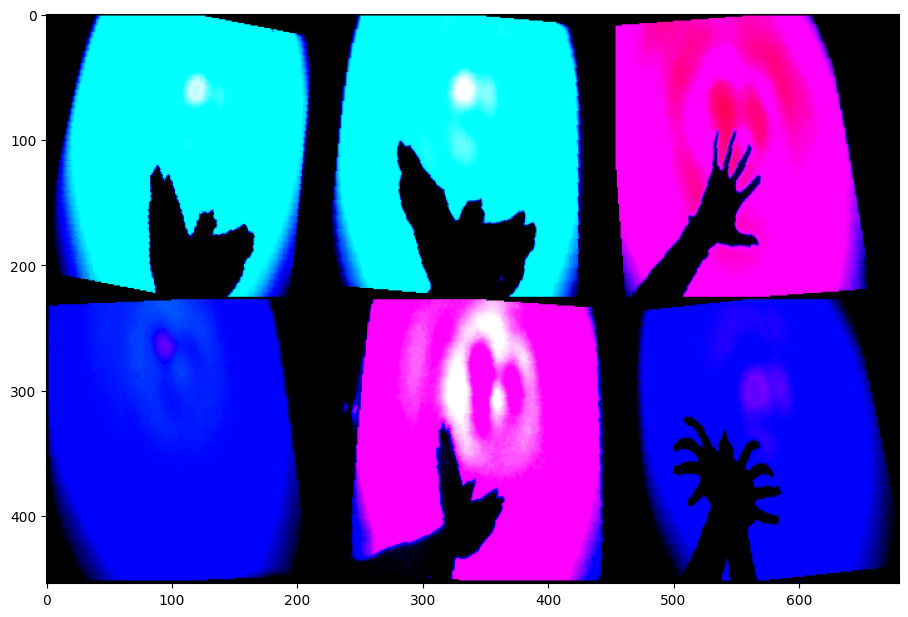

In [38]:
show_transformed_images(train_dataset)

In [39]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size = 32,shuffle=False)

In [40]:
def set_device():
    if torch.cuda.is_available():
        dev = "cuda:0" #gpu
    else:
        dev = "cpu" #cpu
    return torch.device(dev)

In [41]:
def train_nn(model, train_loader, test_loader, criterion, optimizer, n_epochs):
    device = set_device()
    best_acc = 0

    for epoch in range(n_epochs): #epoch is a full trip in dataset
        print ("Epoch number %d " % (epoch + 1))
        model.train()
        running_loss = 0.0
        running_correct = 0.0
        total = 0

        for data in train_loader: #Every data in train loader
            images, labels = data
            images = images.to(device) #moves img & ans to gpu
            labels = labels.to(device) #moves img & ans to gpu
            total += labels.size(0)

            optimizer.zero_grad() #clears grade so previous batch old mistake dont get consufed with new mat
            outputs = model(images)

            _ , predicted = torch.max(outputs.data, 1)
            loss = criterion(outputs, labels) 
            loss.backward()# AI checks the criterion and sees how wrong it is and tracks the error backwards
            optimizer.step() #Tweaks internal weight so that it can guess better next time

            running_loss += loss.item() # Adds up the bad guesses
            running_correct += (labels==predicted).sum().item() #looks at all the 32 img and sums how many the ai got right and put in a scoreboard

            epoch_loss = running_loss/len(train_loader)
            epoch_acc = 100.00 * running_correct / total
            print("    - Training dataset. Got %d out of %d images correctly (%.3f%%). Epoch loss: %.3f" % (running_correct, total, epoch_acc, epoch_loss))
            
    test_dataset_acc = evaluate_model_on_test_set(model, test_loader) # AI tests itself using the pic it never seen b4.. if its score higher than prev score, it saves a backup of its brain so that will always have the best answers

    if(test_dataset_acc > best_acc):
        best_acc = test_dataset_acc
        save_checkpoint(model,epoch,optimizer,best_acc)

    print("Finished")
    return model


In [42]:
def evaluate_model_on_test_set(model, test_loader): 
        model.eval() # It is the testing mode
        predicted_correctly_on_epoch = 0
        total = 0
        device = set_device()

        with torch.no_grad(): # Like a exam closed book, no more learning  and do what uk
               for data in test_loader:
                    images, labels = data
                    images = images.to(device)
                    labels = labels.to(device)
                    total += labels.size(0)
                    
                    outputs = model(images)

                    _, predicted = torch.max(outputs.data, 1) # Gives results and shows how much it got
                    predicted_correctly_on_epoch += (predicted == labels).sum().item()
        epoch_acc = 100.0 * predicted_correctly_on_epoch / total
        print("    - Testing dataset. Got %d out of %d images correctly (%.3f%%)"
                % (predicted_correctly_on_epoch, total, epoch_acc))
        return epoch_acc

        

In [43]:
def save_checkpoint(model,epoch,optimizer,best_acc): #saves checkpoints
    state = {
        'epoch' : epoch + 1, # Saves the best epoch.. if got smt higher, it will update to it
        'model' : model.state_dict(), #Extracts the knowledge the ai learnt
        'best accuracy' : best_acc, # Saves the highest score precentage
        'optimizer' : optimizer.state_dict(), # saves the exact state of the learning engine( tracking how fast / slow it was adjusting its brain)
        'comments' : 'very cool model!'   
        }
    torch.save(state, 'model_best_checkpoint.pth.tar') # saves as a file

In [44]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

resnet18_model = models.resnet18(weights='IMAGENET1K_V1') # a neural network have has millions of images and knows how to recognise alot of things
num_ftrs = resnet18_model.fc.in_features
number_of_classes = 10 # resnet18 was trained to guess alot of abj.. so it is tailored to exacly 10 types images that i have
resnet18_model.fc = nn.Linear(num_ftrs, number_of_classes)
device = set_device() # AI brain moves into the gpu, math-ing faster
resnet_18_model = resnet18_model.to(device)
loss_fn = nn.CrossEntropyLoss() #sees how far the AI guess are from the correct ans

optimizer = optim.SGD(resnet18_model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.003) #SGD algorithm to tweak the learning rate to make sure AI gets it right the next time

In [45]:
train_nn(resnet18_model, train_loader, test_loader, loss_fn, optimizer, 10)

Epoch number 1 
    - Training dataset. Got 3 out of 32 images correctly (9.375%). Epoch loss: 0.083
    - Training dataset. Got 11 out of 64 images correctly (17.188%). Epoch loss: 0.147
    - Training dataset. Got 18 out of 96 images correctly (18.750%). Epoch loss: 0.194
    - Training dataset. Got 32 out of 128 images correctly (25.000%). Epoch loss: 0.232
    - Training dataset. Got 57 out of 160 images correctly (35.625%). Epoch loss: 0.258
    - Training dataset. Got 84 out of 192 images correctly (43.750%). Epoch loss: 0.278
    - Training dataset. Got 107 out of 224 images correctly (47.768%). Epoch loss: 0.299
    - Training dataset. Got 131 out of 256 images correctly (51.172%). Epoch loss: 0.320
    - Training dataset. Got 157 out of 288 images correctly (54.514%). Epoch loss: 0.336
    - Training dataset. Got 187 out of 320 images correctly (58.438%). Epoch loss: 0.346
    - Training dataset. Got 217 out of 352 images correctly (61.648%). Epoch loss: 0.355
    - Training d

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [46]:
checkpoint = torch.load('model_best_checkpoint.pth.tar') # load checkpoint

In [47]:
print(checkpoint['epoch'])
print(checkpoint['comments'])
print(checkpoint['best accuracy'])

10
very cool model!
99.90366088631984


In [48]:
import torch.optim as optim
import torchvision.models as models
import torch.nn as nn
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load folders from the corrected path
train_dataset = ImageFolder(root=train_dataset_path, transform=train_transforms)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Dynamically extract all 5 classes (Background, Bird, Palm, Spider, Wolf)
classes = train_dataset.classes
number_of_classes = len(classes)

print("--- VERIFYING DETECTED SYSTEM DIRECTORIES ---")
print(f"Detected Classes on drive: {classes}")
print(f"Index Mapping: {train_dataset.class_to_idx}")
print("--------------------------------------------\n")

# Load a clean pre-trained ResNet18 backbone
resnet18_model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = resnet18_model.fc.in_features

# Set output channels to 5
resnet18_model.fc = nn.Linear(num_ftrs, number_of_classes) 
resnet18_model = resnet18_model.to(device)

criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(resnet18_model.parameters(), lr=0.001)

print(f"Training a 5-class model across {len(train_dataset)} total images...")
resnet18_model.train()

for epoch in range(5):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = resnet18_model(images)
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/5 finished. Loss: {running_loss/len(train_loader):.4f}")

torch.save(resnet18_model, 'best_model.pth')
print("\nSuccess! 5-Class Model trained and saved as best_model.pth!")

--- VERIFYING DETECTED SYSTEM DIRECTORIES ---
Detected Classes on drive: ['Background', 'Bird', 'Palm', 'Spider', 'Wolf']
Index Mapping: {'Background': 0, 'Bird': 1, 'Palm': 2, 'Spider': 3, 'Wolf': 4}
--------------------------------------------

Training a 5-class model across 1038 total images...
Epoch 1/5 finished. Loss: 0.2631
Epoch 2/5 finished. Loss: 0.0935
Epoch 3/5 finished. Loss: 0.1730
Epoch 4/5 finished. Loss: 0.0971
Epoch 5/5 finished. Loss: 0.0583

Success! 5-Class Model trained and saved as best_model.pth!
